In [13]:
import os
import numpy as np
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from dataclasses import dataclass
from sklearn.metrics import jaccard_score, f1_score
import itertools

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

import torchvision
import torchvision.transforms.functional as F
import torchvision.transforms.v2 as transforms

In [2]:
@dataclass
class Config:
    image_size = (128, 128)
    batch_size = 32
    epochs = 15
    learning_rate = 0.0001
    device = "cuda" if torch.cuda.is_available() else "cpu"
    train_split = 0.8

config = Config()

In [3]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class Up(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(Up, self).__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]

        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])

        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()

        self.inc = DoubleConv(in_channels, 64)
        self.down1 = nn.MaxPool2d(2)
        self.conv1 = DoubleConv(64, 128)
        self.down2 = nn.MaxPool2d(2)
        self.conv2 = DoubleConv(128, 256)
        self.down3 = nn.MaxPool2d(2)
        self.conv3 = DoubleConv(256, 512)
        self.down4 = nn.MaxPool2d(2)
        self.conv4 = DoubleConv(512, 1024)

        self.up1 = Up(1024, 512)
        self.up2 = Up(512, 256)
        self.up3 = Up(256, 128)
        self.up4 = Up(128, 64)
        self.outc = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.conv1(self.down1(x1))
        x3 = self.conv2(self.down2(x2))
        x4 = self.conv3(self.down3(x3))
        x5 = self.conv4(self.down4(x4))

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)

        return logits

In [4]:
class PetDataset(Dataset):
    def __init__(self, root, split='trainval', transform=None):
        self.root = root
        self.transform = transform
        self.dataset = torchvision.datasets.OxfordIIITPet(root=root, split=split, target_types='segmentation', download=True)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]

        mask = np.array(mask)
        mask = (mask > 1).astype(np.uint8)
        mask = Image.fromarray(mask)

        if self.transform:
            image = self.transform(image)

        mask = mask.resize((128, 128))
        mask = F.pil_to_tensor(mask).float()

        return image, mask

In [28]:
class Trainer:
    def __init__(self, config, model_name='UNet'):
        self.config = config
        self.model_name = model_name
        self.history = {'train_loss': [], 'val_loss': [], 'val_iou': [], 'val_f1': []}

        self.transform = transforms.Compose([
            transforms.Resize(config.image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5])
        ])

        if self.model_name == 'UNet':
            self.model = UNet().to(config.device)
        elif self.model_name == 'ResUNet':
            self.model = ResUNet().to(config.device)
        else:
            raise ValueError(f"Unsupported model name: {self.model_name}")

        self.criterion = nn.BCEWithLogitsLoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.learning_rate)

        self.setup_dataloader()

    def setup_dataloader(self):
        dataset = PetDataset(root="./data", split='trainval', transform=self.transform)
        train_size = int(self.config.train_split * len(dataset))
        val_size = len(dataset) - train_size

        train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
        self.test_dataset = PetDataset(root="./data", split='test', transform=self.transform)

        self.train_dataloader = DataLoader(train_dataset, batch_size=self.config.batch_size, shuffle=True)
        self.val_dataloader = DataLoader(val_dataset, batch_size=self.config.batch_size, shuffle=False)
        self.test_dataloader = DataLoader(self.test_dataset, batch_size=self.config.batch_size, shuffle=False)

    def run(self):
        self.history = {'train_loss': [], 'val_loss': [], 'val_iou': [], 'val_f1': []}

        for epoch in range(self.config.epochs):
            train_loss = self.train()
            val_loss, val_iou, val_f1 = self.validate()

            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['val_iou'].append(val_iou)
            self.history['val_f1'].append(val_f1)

            print(f"Epoch {epoch+1} / {self.config.epochs}, "
                  f"Train Loss: {train_loss:.4f}, "
                  f"Val Loss: {val_loss:.4f}, "
                  f"Val IoU: {val_iou:.4f}, "
                  f"Val F1-score: {val_f1:.4f}")

        self.plot_training_history()

        print('Testing...')
        test_loss, test_iou, test_f1 = self.test()
        print(f"Test Loss: {test_loss:.4f}, Test IoU: {test_iou:.4f}, Test F1-score: {test_f1:.4f}")

    def plot_training_history(self):
        epochs = range(1, len(self.history['train_loss']) + 1)
        fig, ax1 = plt.subplots(figsize=(12, 5))

        ax1.set_xlabel('Epochs')
        ax1.set_ylabel('Loss', color='tab:red')
        ax1.plot(epochs, self.history['train_loss'], label='Train Loss', color='tab:red', linestyle='--')
        ax1.plot(epochs, self.history['val_loss'], label='Val Loss', color='tab:orange')
        ax1.tick_params(axis='y', labelcolor='tab:red')
        ax1.legend(loc='upper left')

        ax2 = ax1.twinx()
        ax2.set_ylabel('Metrics', color='tab:blue')
        ax2.plot(epochs, self.history['val_iou'], label='Val IoU', color='tab:blue')
        ax2.plot(epochs, self.history['val_f1'], label='Val F1', color='tab:cyan')
        ax2.tick_params(axis='y', labelcolor='tab:blue')
        ax2.legend(loc='upper right')

        plt.title(f'Training History - {self.model_name}')
        fig.tight_layout()
        plt.show()

    def train(self):
        self.model.train()
        epoch_loss = 0
        for images, masks in tqdm(self.train_dataloader, desc="Training", leave=False):
            images, masks = images.to(self.config.device), masks.to(self.config.device)
            self.optimizer.zero_grad()
            outputs = self.model(images)
            loss = self.criterion(outputs, masks)
            loss.backward()
            self.optimizer.step()
            epoch_loss += loss.item()
        return epoch_loss / len(self.train_dataloader)

    def validate(self):
        self.model.eval()
        val_loss, iou_scores, f1_scores = 0, [], []
        with torch.no_grad():
            for images, masks in tqdm(self.val_dataloader, desc="Validating", leave=False):
                images, masks = images.to(self.config.device), masks.to(self.config.device)
                outputs = self.model(images)
                val_loss += self.criterion(outputs, masks).item()
                pred_masks = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                masks_np = masks.squeeze(1).cpu().numpy().astype(np.uint8)
                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks_np[i].flatten(), pred_masks[i].flatten(), average='binary', zero_division=1))
                    f1_scores.append(f1_score(masks_np[i].flatten(), pred_masks[i].flatten(), average='binary', zero_division=1))
        return val_loss / len(self.val_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def test(self):
        self.model.eval()
        test_loss, iou_scores, f1_scores = 0, [], []
        with torch.no_grad():
            for images, masks in tqdm(self.test_dataloader, desc="Testing", leave=False):
                images, masks = images.to(self.config.device), masks.to(self.config.device)
                outputs = self.model(images)
                test_loss += self.criterion(outputs, masks).item()
                pred_masks = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                masks_np = masks.squeeze(1).cpu().numpy().astype(np.uint8)
                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks_np[i].flatten(), pred_masks[i].flatten(), average='binary', zero_division=1))
                    f1_scores.append(f1_score(masks_np[i].flatten(), pred_masks[i].flatten(), average='binary', zero_division=1))
        return test_loss / len(self.test_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def inference_and_plot_samples(self, n_samples=3):
        self.model.eval()
        with torch.no_grad():
            fig, axes = plt.subplots(n_samples, 3, figsize=(10, 3 * n_samples))
            for i in range(n_samples):
                img, mask = self.test_dataset[i]
                img_tensor = img.unsqueeze(0).to(self.config.device)
                output = torch.sigmoid(self.model(img_tensor)).squeeze().cpu().numpy()
                output = (output >= 0.5).astype('float')
                display_img = (img.permute(1, 2, 0).cpu().numpy() * 0.5) + 0.5
                axes[i, 0].imshow(np.clip(display_img, 0, 1))
                axes[i, 0].set_title("Image")
                axes[i, 1].imshow(mask.squeeze().cpu(), cmap="gray")
                axes[i, 1].set_title("Ground Truth")
                axes[i, 2].imshow(output, cmap="gray")
                axes[i, 2].set_title("Predicted Mask")
            plt.tight_layout()
            plt.show()

    def tune_hyperparameters(self, param_grid, trial_epochs=5):
        best_val_f1, best_config_params = -1.0, {}
        base_config_dict = {attr: getattr(self.config, attr) for attr in dir(self.config) if not attr.startswith('__') and not callable(getattr(self.config, attr))}
        keys, values = param_grid.keys(), param_grid.values()
        all_combinations = list(itertools.product(*values))
        print("Starting hyperparameter tuning...")
        for i, params in enumerate(all_combinations):
            current_params = dict(zip(keys, params))
            print(f"\nTrial {i+1}/{len(all_combinations)}: {current_params}")
            trial_config = Config()
            for k, v in base_config_dict.items(): setattr(trial_config, k, v)
            for k, v in current_params.items(): setattr(trial_config, k, v)
            self.config = trial_config
            self.model = (UNet() if self.model_name == 'UNet' else ResUNet()).to(self.config.device)
            self.optimizer = optim.Adam(self.model.parameters(), lr=self.config.learning_rate)
            self.setup_dataloader()
            for epoch in range(trial_epochs):
                self.train()
                _, _, val_f1 = self.validate()
            if val_f1 > best_val_f1:
                best_val_f1, best_config_params = val_f1, current_params
                print(f"  New best: {best_config_params} F1: {best_val_f1:.4f}")
        for k, v in best_config_params.items(): setattr(self.config, k, v)
        self.model = (UNet() if self.model_name == 'UNet' else ResUNet()).to(self.config.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.config.learning_rate)
        self.setup_dataloader()
        print("Trainer updated with best config.")

In [16]:
trainer = Trainer(config, model_name='UNet')

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [17]:
param_grid = {
    'learning_rate': [0.001, 0.0001, 0.00001],
    'batch_size': [16, 32, 64]
}

trainer.tune_hyperparameters(param_grid, trial_epochs=5)

Starting hyperparameter tuning...

Trial 1/9
Testing config: {'learning_rate': 0.001, 'batch_size': 16}


100%|██████████| 46/46 [00:11<00:00,  3.85it/s]


  Epoch 1/5 - Val Loss: 0.3962, Val IoU: 0.7606, Val F1: 0.8586


100%|██████████| 46/46 [00:11<00:00,  3.95it/s]


  Epoch 2/5 - Val Loss: 0.3726, Val IoU: 0.7867, Val F1: 0.8743


...

  Epoch 3/5 - Val Loss: 0.4419, Val IoU: 0.7816, Val F1: 0.8726


100%|██████████| 12/12 [00:12<00:00,  1.01s/it]


  Epoch 4/5 - Val Loss: 0.3903, Val IoU: 0.8172, Val F1: 0.8943


100%|██████████| 12/12 [00:11<00:00,  1.01it/s]


  Epoch 5/5 - Val Loss: 0.4143, Val IoU: 0.7915, Val F1: 0.8782

Hyperparameter tuning complete. Best config: {'learning_rate': 0.0001, 'batch_size': 16}
Best validation F1-score: 0.9289
Trainer's config updated


learning rate 0.0001 оказался золотой серединой -- не перепрыгивает минимумы, но и не застревает в локальных ямках

судя по всему батч сайз 16 лучше, так как дал модели более шумную оценку градиента, позволяя выбираться из плоских локальных минимумов
{'learning_rate': 0.0001, 'batch_size': 16}

In [18]:
trainer.run()

100%|██████████| 46/46 [00:11<00:00,  3.93it/s]


Epoch 1 / 15, Train Loss: 0.4405, Val Loss: 0.3242, Val IoU: 0.8138, Val F1-score: 0.8923


100%|██████████| 46/46 [00:11<00:00,  3.85it/s]


Epoch 2 / 15, Train Loss: 0.3194, Val Loss: 0.2913, Val IoU: 0.8470, Val F1-score: 0.9126


100%|██████████| 46/46 [00:11<00:00,  3.86it/s]


...

Epoch 14 / 15, Train Loss: 0.1088, Val Loss: 0.1953, Val IoU: 0.8938, Val F1-score: 0.9412


100%|██████████| 46/46 [00:11<00:00,  3.88it/s]


Epoch 15 / 15, Train Loss: 0.1089, Val Loss: 0.1912, Val IoU: 0.8945, Val F1-score: 0.9417
Testing...


100%|██████████| 230/230 [01:01<00:00,  3.73it/s]

Test Loss: 0.2026, Test IoU: 0.8871, Test F1-score: 0.9362


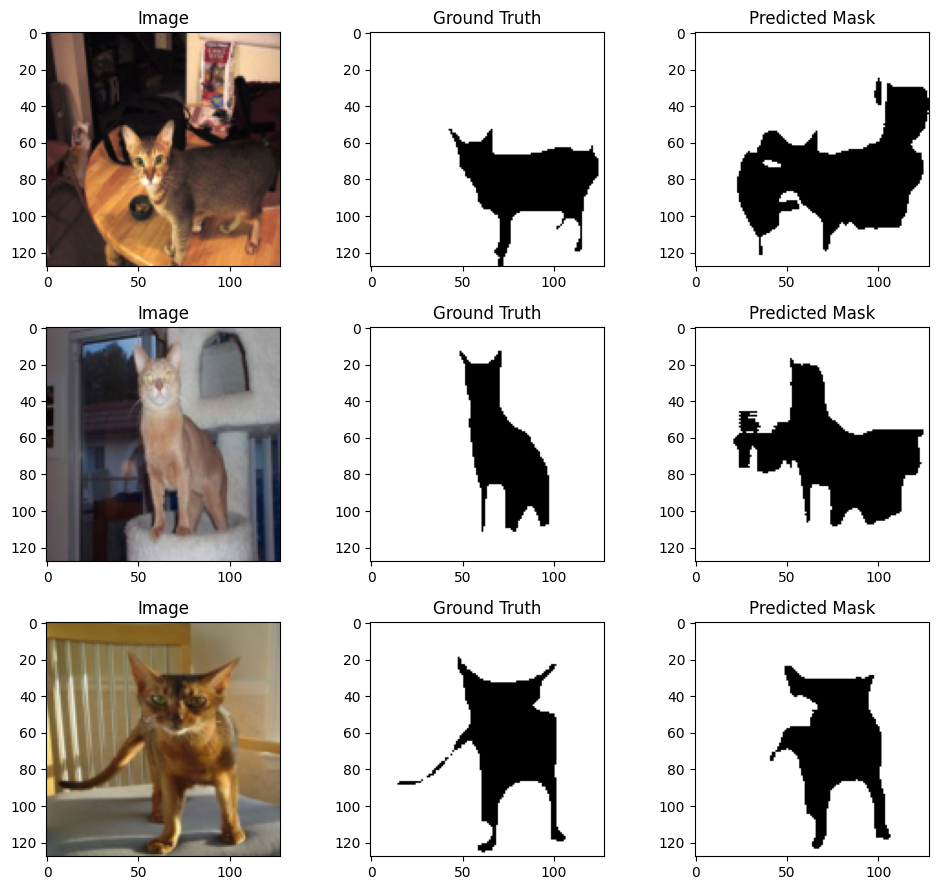

In [20]:
trainer.inference_and_plot_samples(n_samples=3)

In [19]:
# Добавил res связи и дропауты
class ResidualDoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.shortcut = nn.Sequential()
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += identity
        out = self.relu(out)
        return out


class ResUp(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        self.conv = ResidualDoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class ResUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, dropout_prob=0.3):
        super().__init__()
        self.inc = ResidualDoubleConv(in_channels, 64)
        self.down1 = nn.MaxPool2d(2)
        self.conv1 = ResidualDoubleConv(64, 128)
        self.down2 = nn.MaxPool2d(2)
        self.conv2 = ResidualDoubleConv(128, 256)
        self.down3 = nn.MaxPool2d(2)
        self.conv3 = ResidualDoubleConv(256, 512)
        self.down4 = nn.MaxPool2d(2)
        self.conv4 = ResidualDoubleConv(512, 1024)

        self.dropout = nn.Dropout2d(p=dropout_prob)

        self.up1 = ResUp(1024, 512)
        self.up2 = ResUp(512, 256)
        self.up3 = ResUp(256, 128)
        self.up4 = ResUp(128, 64)
        self.outc = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.conv1(self.down1(x1))
        x3 = self.conv2(self.down2(x2))
        x4 = self.conv3(self.down3(x3))
        x5 = self.conv4(self.down4(x4))

        x5 = self.dropout(x5)

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return logits

In [23]:
trainer_res = Trainer(config, model_name='ResUNet')

In [24]:
trainer_res.tune_hyperparameters(param_grid, trial_epochs=3)

Starting hyperparameter tuning...

Trial 1/9
Testing config: {'learning_rate': 0.001, 'batch_size': 16}


100%|██████████| 46/46 [00:12<00:00,  3.77it/s]


  Epoch 1/3 - Val Loss: 0.3667, Val IoU: 0.7815, Val F1: 0.8705


100%|██████████| 46/46 [00:12<00:00,  3.78it/s]


  Epoch 2/3 - Val Loss: 0.2895, Val IoU: 0.8281, Val F1: 0.9008


...

  Epoch 1/3 - Val Loss: 0.5921, Val IoU: 0.6177, Val F1: 0.7546


100%|██████████| 12/12 [00:12<00:00,  1.06s/it]


  Epoch 2/3 - Val Loss: 0.4335, Val IoU: 0.7796, Val F1: 0.8682


100%|██████████| 12/12 [00:12<00:00,  1.06s/it]

  Epoch 3/3 - Val Loss: 0.4088, Val IoU: 0.7813, Val F1: 0.8681

Hyperparameter tuning complete. Best config: {'learning_rate': 0.0001, 'batch_size': 32}
Best validation F1-score: 0.9135
Trainer's config updated


{'learning_rate': 0.0001, 'batch_size': 32}

In [25]:
trainer_res.run()

100%|██████████| 23/23 [00:12<00:00,  1.86it/s]


Epoch 1 / 15, Train Loss: 0.3722, Val Loss: 0.3092, Val IoU: 0.8280, Val F1-score: 0.9006


100%|██████████| 23/23 [00:12<00:00,  1.88it/s]


Epoch 2 / 15, Train Loss: 0.2926, Val Loss: 0.2846, Val IoU: 0.8384, Val F1-score: 0.9067


100%|██████████| 23/23 [00:12<00:00,  1.91it/s]


...

Epoch 14 / 15, Train Loss: 0.0966, Val Loss: 0.2520, Val IoU: 0.8650, Val F1-score: 0.9235


100%|██████████| 23/23 [00:12<00:00,  1.88it/s]


Epoch 15 / 15, Train Loss: 0.0894, Val Loss: 0.2430, Val IoU: 0.8814, Val F1-score: 0.9330
Testing...


100%|██████████| 115/115 [01:01<00:00,  1.87it/s]

Test Loss: 0.2474, Test IoU: 0.8795, Test F1-score: 0.9309


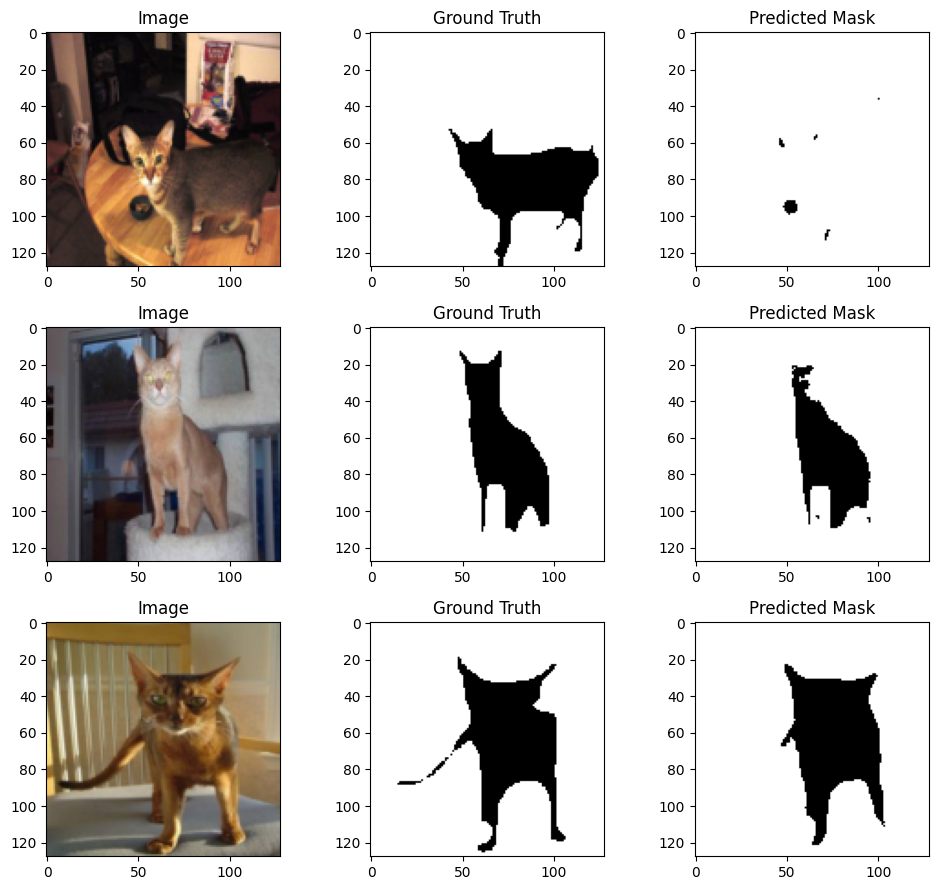

In [26]:
trainer_res.inference_and_plot_samples(n_samples=3)

100%|██████████| 115/115 [01:00<00:00,  1.90it/s]


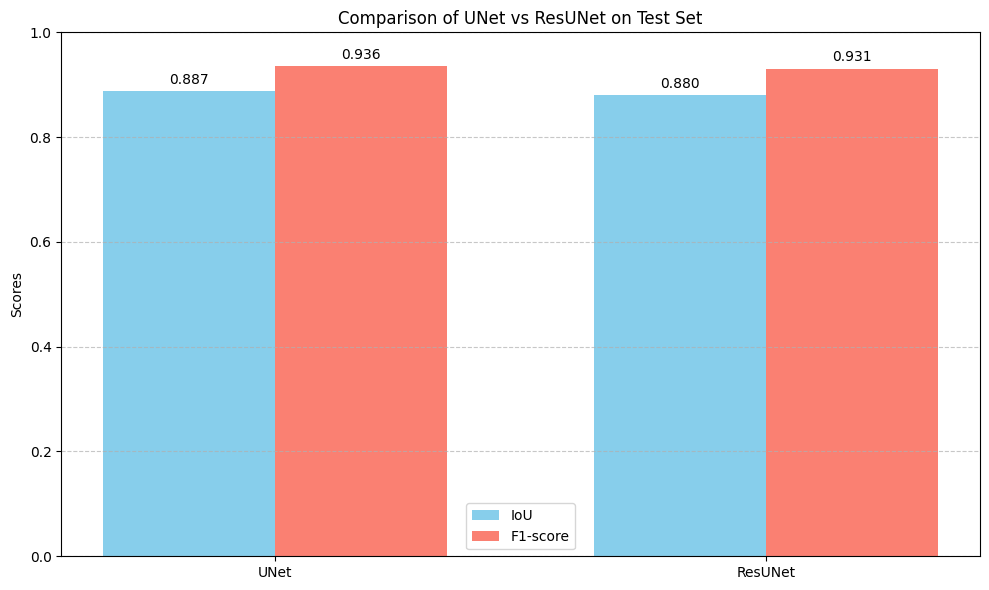

In [29]:
def compare_models(trainer_list):
    results = []
    for trainer in trainer_list:
        loss, iou, f1 = trainer.test()
        results.append({'IoU': iou, 'F1-score': f1})
    names = [trainer.model_name for trainer in trainer_list]
    x = np.arange(len(names))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    ious = [r['IoU'] for r in results]
    f1s = [r['F1-score'] for r in results]

    rects1 = ax.bar(x - width/2, ious, width, label='IoU', color='skyblue')
    rects2 = ax.bar(x + width/2, f1s, width, label='F1-score', color='salmon')

    ax.set_ylabel('Scores')
    ax.set_title('Comparison of UNet vs ResUNet on Test Set')
    ax.set_xticks(x)
    ax.set_xticklabels(names)
    ax.set_ylim(0, 1.0)
    ax.legend()

    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.3f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom')

    autolabel(rects1)
    autolabel(rects2)

    fig.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

compare_models([trainer, trainer_res])

короче тут я захотел сделать ещё графики по метрикам во время обучения, а переделывать ячейки до этого мне стало впадлу чутка, поэтому вооот...

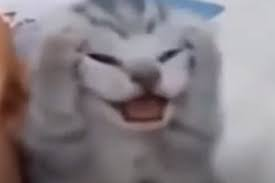

In [30]:
config_unet = Config()
config_unet.learning_rate = 0.0001
config_unet.batch_size = 16

config_resunet = Config()
config_resunet.learning_rate = 0.0001
config_resunet.batch_size = 32

In [31]:
stat_trainer_unet = Trainer(config_unet, 'UNet')

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [32]:
stat_trainer_resunet = Trainer(config_unet, 'ResUNet')

Epoch 1 / 15, Train Loss: 0.4591, Val Loss: 0.3729, Val IoU: 0.8086, Val F1-score: 0.8882


Epoch 2 / 15, Train Loss: 0.3334, Val Loss: 0.3020, Val IoU: 0.8427, Val F1-score: 0.9092


Epoch 3 / 15, Train Loss: 0.2839, Val Loss: 0.2683, Val IoU: 0.8495, Val F1-score: 0.9137


Epoch 4 / 15, Train Loss: 0.2525, Val Loss: 0.2421, Val IoU: 0.8619, Val F1-score: 0.9216


Epoch 5 / 15, Train Loss: 0.2246, Val Loss: 0.2405, Val IoU: 0.8641, Val F1-score: 0.9227


...

Epoch 11 / 15, Train Loss: 0.1363, Val Loss: 0.1838, Val IoU: 0.8913, Val F1-score: 0.9390


Epoch 12 / 15, Train Loss: 0.1295, Val Loss: 0.2022, Val IoU: 0.8810, Val F1-score: 0.9325


Epoch 13 / 15, Train Loss: 0.1215, Val Loss: 0.1973, Val IoU: 0.8855, Val F1-score: 0.9355


Epoch 14 / 15, Train Loss: 0.1150, Val Loss: 0.2282, Val IoU: 0.8794, Val F1-score: 0.9314


Epoch 15 / 15, Train Loss: 0.1130, Val Loss: 0.1909, Val IoU: 0.8947, Val F1-score: 0.9410


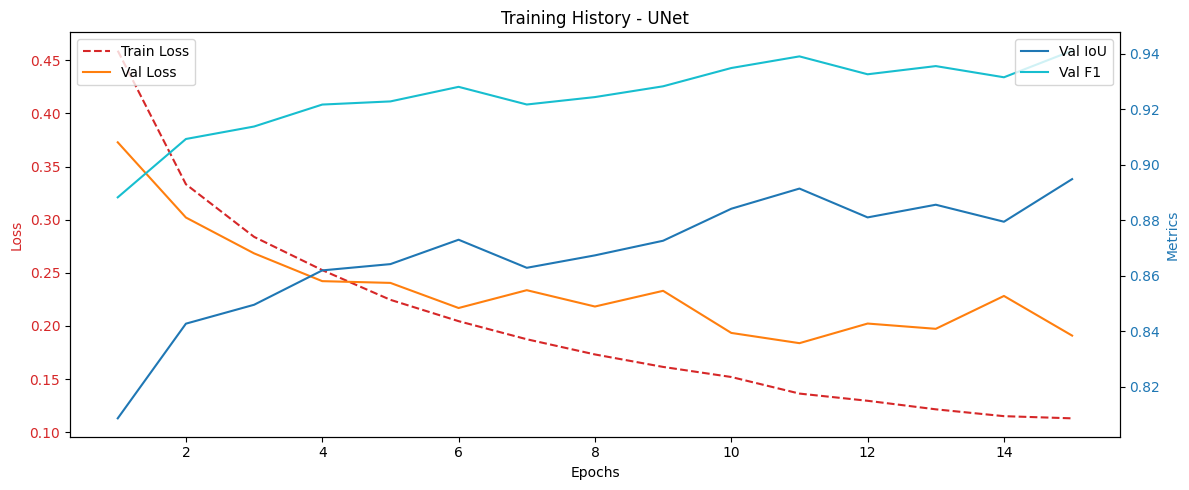

Testing...


Test Loss: 0.1929, Test IoU: 0.8930, Test F1-score: 0.9394


In [33]:
stat_trainer_unet.run()

Epoch 1 / 15, Train Loss: 0.4144, Val Loss: 0.3347, Val IoU: 0.8165, Val F1-score: 0.8927


Epoch 2 / 15, Train Loss: 0.2938, Val Loss: 0.3075, Val IoU: 0.8222, Val F1-score: 0.8975


Epoch 3 / 15, Train Loss: 0.2529, Val Loss: 0.2472, Val IoU: 0.8568, Val F1-score: 0.9186


Epoch 4 / 15, Train Loss: 0.2230, Val Loss: 0.2839, Val IoU: 0.8433, Val F1-score: 0.9090


Epoch 5 / 15, Train Loss: 0.2043, Val Loss: 0.2233, Val IoU: 0.8653, Val F1-score: 0.9239


...

Epoch 11 / 15, Train Loss: 0.1148, Val Loss: 0.2237, Val IoU: 0.8808, Val F1-score: 0.9326


Epoch 12 / 15, Train Loss: 0.1089, Val Loss: 0.2182, Val IoU: 0.8766, Val F1-score: 0.9302


Epoch 13 / 15, Train Loss: 0.1098, Val Loss: 0.2135, Val IoU: 0.8872, Val F1-score: 0.9370


Epoch 14 / 15, Train Loss: 0.0971, Val Loss: 0.2171, Val IoU: 0.8820, Val F1-score: 0.9336


Epoch 15 / 15, Train Loss: 0.0865, Val Loss: 0.1977, Val IoU: 0.8946, Val F1-score: 0.9415


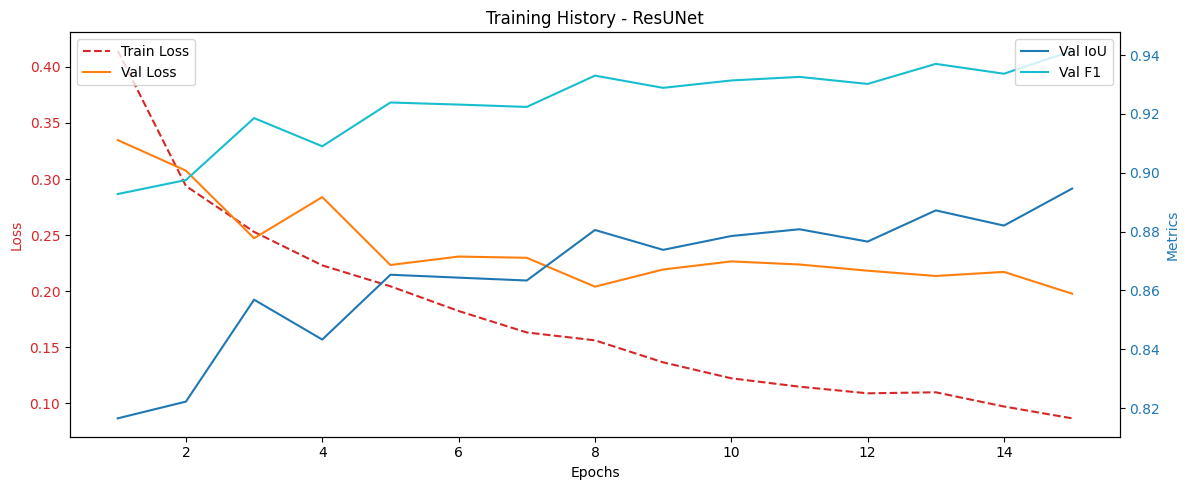

Testing...


Test Loss: 0.1952, Test IoU: 0.8928, Test F1-score: 0.9395


In [34]:
stat_trainer_resunet.run()

Короче мб стоило углублять сеть, или получше подбор гиперпараметров делать, но улучшение от residual связей практически нет